**CELL 1: Imports and Setup**

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import Normalize
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, LSTM,
                                     Conv1D, MaxPooling1D, Dense, Dropout,
                                     GlobalMaxPooling1D, BatchNormalization)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import imageio
import warnings
warnings.filterwarnings('ignore')

# Output folder where all generated images, GIFs, and plots are saved
OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.19.0
GPU available: 2


**CELL 2: List Avialable Dataset Files (Sanity Check)**

In [5]:
import os

print("Files under /kaggle/input:")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Files under /kaggle/input:
/kaggle/input/datasets/alfrandom/protein-secondary-structure/2018-06-06-ss.cleaned.csv
/kaggle/input/datasets/alfrandom/protein-secondary-structure/2018-06-06-pdb-intersect-pisces.csv


**CELL 3: Load The Cleaned CSV**

In [6]:
import pandas as pd

DATA_DIR = '/kaggle/input/datasets/alfrandom/protein-secondary-structure'

filepath = f'{DATA_DIR}/2018-06-06-ss.cleaned.csv'
df = pd.read_csv(filepath)

print(df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())

(393732, 7)
  pdb_id chain_code  seq sst8 sst3  len  has_nonstd_aa
0   1A30          C  EDL  CBC  CEC    3          False
1   1B05          B  KCK  CBC  CEC    3          False
2   1B0H          B  KAK  CBC  CEC    3          False
3   1B1H          B  KFK  CBC  CEC    3          False
4   1B2H          B  KAK  CBC  CEC    3          False

Columns: ['pdb_id', 'chain_code', 'seq', 'sst8', 'sst3', 'len', 'has_nonstd_aa']


**CELL 4: Filter and Basic Cleaning**

In [22]:
# Keep only needed columns
df = df[['seq', 'sst3', 'len', 'has_nonstd_aa']]

# Drop any NaNs just in case
df = df.dropna(subset=['seq', 'sst3'])

# Filter out sequences with non-standard amino acids
df = df[df['has_nonstd_aa'] == False].reset_index(drop=True)

# Filter by length to remove extremely short/long fragments
df = df[(df['len'] >= 50) & (df['len'] <= 500)].reset_index(drop=True)

print(f"After basic filtering: {len(df)} sequences")

# === KEY STEP TO LIMIT TRAIN TIME ===
# Sample a subset of sequences to keep training within ~3 hours.
# With 60,000 sequences, the simpler BiLSTM model should train
# in roughly 1–3 hours on T4x2 depending on final epoch count.
TARGET_N = 60000  # adjust if you want slightly more/less data

if len(df) > TARGET_N:
    df = df.sample(n=TARGET_N, random_state=42).reset_index(drop=True)
    print(f"Subsampled to {TARGET_N} sequences for faster training.")
else:
    print("Dataset smaller than TARGET_N; using all sequences.")

print(f"Final dataset size used for training: {len(df)}")
print(f"Sequence length range: {df['len'].min()} to {df['len'].max()}")
print(f"Average length: {df['len'].mean():.1f}")

After basic filtering: 333791 sequences
Subsampled to 60000 sequences for faster training.
Final dataset size used for training: 60000
Sequence length range: 50 to 500
Average length: 232.0


**CELL 5: Encode Sequences and Labels**

In [23]:
# Define the 20 standard amino acids
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')
aa_to_idx = {aa: idx + 1 for idx, aa in enumerate(AMINO_ACIDS)}  # 1..20, 0 reserved for padding

# Map secondary structure 3-state labels to integers: H, E, C
SS_LABELS = {'H': 0, 'E': 1, 'C': 2}

def encode_sequence(seq):
    # Convert sequence string to list of ints
    return [aa_to_idx.get(aa.upper(), 0) for aa in seq]

def encode_labels(ss_string):
    # Convert sst3 string to list of ints
    return [SS_LABELS.get(c, 2) for c in ss_string]  # default to coil for any unknown

df['seq_encoded']  = df['seq'].apply(encode_sequence)
df['sst3_encoded'] = df['sst3'].apply(encode_labels)

# Sanity: lengths must match
mismatch = df[df['seq_encoded'].apply(len) != df['sst3_encoded'].apply(len)]
print(f"Mismatched pairs: {len(mismatch)}")

df = df[df['seq_encoded'].apply(len) == df['sst3_encoded'].apply(len)].reset_index(drop=True)
print(f"Clean dataset after removing mismatches: {len(df)}")

Mismatched pairs: 0
Clean dataset after removing mismatches: 60000


**CELL 6: Pad Sequences and Labels to Fixed Length**

In [25]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 300  # it can be adjusted

X = pad_sequences(df['seq_encoded'].tolist(),
                  maxlen=MAX_LEN,
                  padding='post',
                  truncating='post',
                  value=0)

y_int = pad_sequences(df['sst3_encoded'].tolist(),
                      maxlen=MAX_LEN,
                      padding='post',
                      truncating='post',
                      value=2)   # padding label as coil

y = to_categorical(y_int, num_classes=3)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (60000, 300)
y shape: (60000, 300, 3)


**CELL 7: Train/Validation/Test Split**

In [26]:
from sklearn.model_selection import train_test_split

# First split train+val vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Split temp into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.18, random_state=42
)

print(f"Train size: {X_train.shape[0]}")
print(f"Val size:   {X_val.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

Train size: 41820
Val size:   9180
Test size:  9000


**CELL 8: Build The Model**

In [27]:
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, LSTM,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.models import Model

VOCAB_SIZE  = len(AMINO_ACIDS) + 1
EMBED_DIM   = 32
NUM_CLASSES = 3

def build_simple_model(vocab_size, embed_dim, max_len, num_classes):
    inputs = Input(shape=(max_len,), name='sequence_input')

    x = Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  mask_zero=True,
                  name='amino_acid_embedding')(inputs)

    x = Bidirectional(
        LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        name='bilstm1'
    )(x)

    x = Dense(32, activation='relu', name='dense1')(x)
    x = Dropout(0.3, name='drop1')(x)

    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='ProteinSS_Simple')
    return model

model = build_simple_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model.summary()

Model: "ProteinSS_Simple"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amino_acid_embeddi… │ (None, 300, 32)   │        672 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 300)       │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm1             │ (None, 300, 128)  │     49,664 │ amino_acid_embed… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 300, 32)   │      4,128 │ bilstm1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 300, 32)   │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 300, 3)    │         99 │ drop1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,563 (213.14 KB)

 Trainable params: 54,563 (213.14 KB)

 Non-trainable params: 0 (0.00 B)

**CELL 9: Compile The Model**

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**CELL 10: Callback to Track Weights Per Epoch**

In [29]:
class WeightTracker(tf.keras.callbacks.Callback):
    def __init__(self, layer_names):
        super().__init__()
        self.layer_names = layer_names
        self.weight_history = {name: [] for name in layer_names}

    def on_epoch_end(self, epoch, logs=None):
        for name in self.layer_names:
            layer = self.model.get_layer(name)
            weights = layer.get_weights()
            if len(weights) > 0:
                self.weight_history[name].append(weights[0].copy())

tracked_layers = ['bilstm1', 'dense1']
weight_tracker = WeightTracker(tracked_layers)

**CELL 11: Train with callbacks**

In [31]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f'{OUTPUT_DIR}/best_model.h5', monitor='val_loss',
                    save_best_only=True, verbose=0),
    weight_tracker
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,  
    callbacks=callbacks,
    verbose=1
)

print("Training complete.")

Epoch 1/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5765 - loss: 0.9082

327/327 ━━━━━━━━━━━━━━━━━━━━ 567s 2s/step - accuracy: 0.6160 - loss: 0.8520 - val_accuracy: 0.6550 - val_loss: 0.7789 - learning_rate: 0.0010
Epoch 2/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6510 - loss: 0.7946

327/327 ━━━━━━━━━━━━━━━━━━━━ 565s 2s/step - accuracy: 0.6573 - loss: 0.7833 - val_accuracy: 0.6815 - val_loss: 0.7295 - learning_rate: 0.0010
Epoch 3/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6740 - loss: 0.7516

327/327 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - accuracy: 0.6774 - loss: 0.7446 - val_accuracy: 0.6964 - val_loss: 0.7004 - learning_rate: 0.0010
Epoch 4/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6856 - loss: 0.7288

327/327 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.6870 - loss: 0.7261 - val_accuracy: 0.7023 - val_loss: 0.6881 - learning_rate: 0.0010
Epoch 5/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6918 - loss: 0.7169

...

327/327 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.7174 - loss: 0.6652 - val_accuracy: 0.7322 - val_loss: 0.6262 - learning_rate: 0.0010
Epoch 16/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7187 - loss: 0.6631

327/327 ━━━━━━━━━━━━━━━━━━━━ 556s 2s/step - accuracy: 0.7186 - loss: 0.6626 - val_accuracy: 0.7348 - val_loss: 0.6207 - learning_rate: 0.0010
Epoch 17/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7193 - loss: 0.6611

327/327 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.7198 - loss: 0.6604 - val_accuracy: 0.7360 - val_loss: 0.6188 - learning_rate: 0.0010
Epoch 18/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 556s 2s/step - accuracy: 0.7208 - loss: 0.6583 - val_accuracy: 0.7353 - val_loss: 0.6200 - learning_rate: 0.0010
Epoch 19/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7216 - loss: 0.6564

327/327 ━━━━━━━━━━━━━━━━━━━━ 557s 2s/step - accuracy: 0.7220 - loss: 0.6559 - val_accuracy: 0.7374 - val_loss: 0.6161 - learning_rate: 0.0010
Epoch 20/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7227 - loss: 0.6547

327/327 ━━━━━━━━━━━━━━━━━━━━ 555s 2s/step - accuracy: 0.7230 - loss: 0.6541 - val_accuracy: 0.7392 - val_loss: 0.6118 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 20.
Training complete.


**CELL 12: Plot Loss and Accuracy Curve**

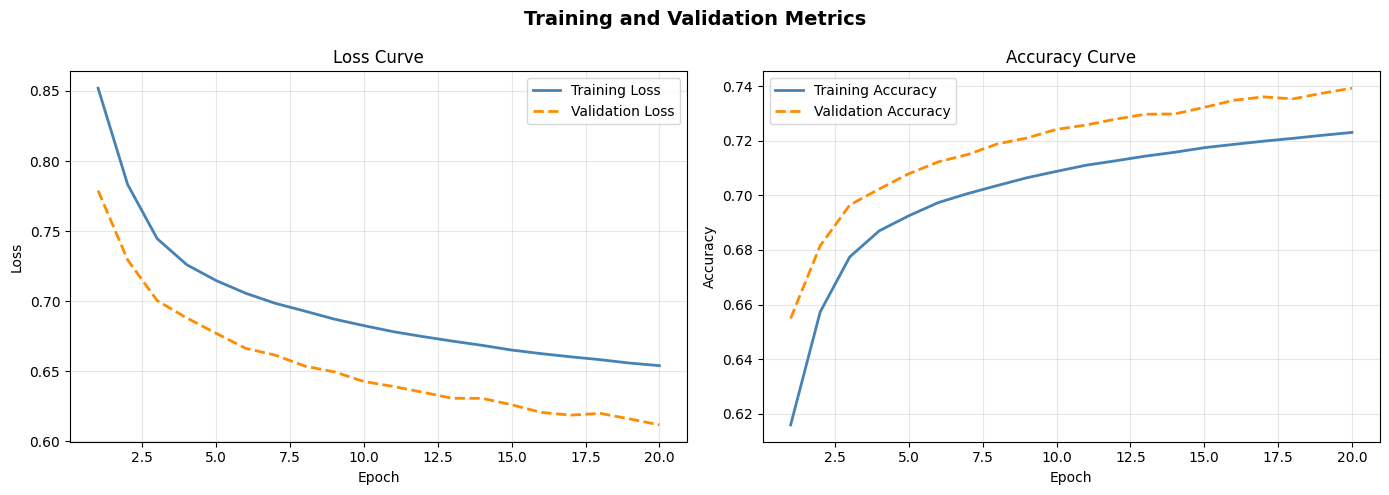

Saved: /kaggle/working/outputs/loss_accuracy_curves.png


In [32]:
def plot_training_curves(history, save_dir):
    epochs_run = range(1, len(history.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training and Validation Metrics', fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(epochs_run, history.history['loss'],
                 label='Training Loss', color='steelblue', linewidth=2)
    axes[0].plot(epochs_run, history.history['val_loss'],
                 label='Validation Loss', color='darkorange',
                 linewidth=2, linestyle='--')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs_run, history.history['accuracy'],
                 label='Training Accuracy', color='steelblue', linewidth=2)
    axes[1].plot(epochs_run, history.history['val_accuracy'],
                 label='Validation Accuracy', color='darkorange',
                 linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'loss_accuracy_curves.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

plot_training_curves(history, OUTPUT_DIR)

**CELL 13: Evaluate on Test Set**

In [33]:
# Predict on test set
y_pred_prob = model.predict(X_test, batch_size=64, verbose=1)

y_pred_flat = y_pred_prob.argmax(axis=-1).flatten()
y_true_flat = y_test.argmax(axis=-1).flatten()

# Mask out padded positions (input token 0)
X_test_flat = X_test.flatten()
valid_mask = X_test_flat != 0

y_pred_masked = y_pred_flat[valid_mask]
y_true_masked = y_true_flat[valid_mask]

print("Classification Report (residue-level, non-padded positions):")
print(classification_report(
    y_true_masked, y_pred_masked,
    target_names=['Helix (H)', 'Sheet (E)', 'Coil (C)'],
    digits=4
))

141/141 ━━━━━━━━━━━━━━━━━━━━ 44s 309ms/step
Classification Report (residue-level, non-padded positions):
              precision    recall  f1-score   support

   Helix (H)     0.7663    0.7779    0.7720    631832
   Sheet (E)     0.7171    0.6240    0.6673    422220
    Coil (C)     0.7257    0.7652    0.7449    831570

    accuracy                         0.7378   1885622
   macro avg     0.7363    0.7223    0.7281   1885622
weighted avg     0.7374    0.7378    0.7366   1885622



**CELL 14: Confusion Matrix**

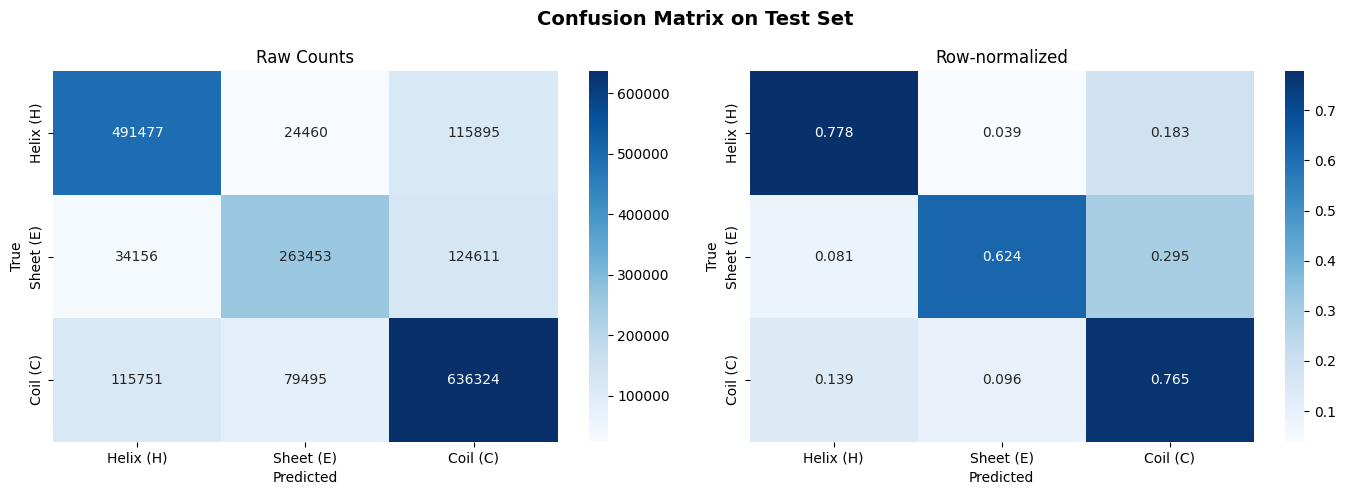

Saved: /kaggle/working/outputs/confusion_matrix.png


In [34]:
def plot_confusion_matrix(y_true, y_pred, class_names, save_dir):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Confusion Matrix on Test Set', fontsize=14, fontweight='bold')

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Raw Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Row-normalized')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

plot_confusion_matrix(
    y_true_masked, y_pred_masked,
    ['Helix (H)', 'Sheet (E)', 'Coil (C)'],
    OUTPUT_DIR
)

**CELL 15: Weight Update GIFS**

In [35]:
def create_weight_gif(weight_history_list, layer_name, save_dir, max_frames=30):
    frames = weight_history_list
    if len(frames) > max_frames:
        step = len(frames) // max_frames
        frames = frames[::step]

    gif_frames = []
    vmin = min(w.min() for w in frames)
    vmax = max(w.max() for w in frames)

    for epoch_idx, weights in enumerate(frames):
        fig, ax = plt.subplots(figsize=(8, 4))

        # Flatten multi-dimensional weights to a 2D map
        w = weights.reshape(-1, weights.shape[-1]) if weights.ndim > 2 else weights
        w_slice = w[:64, :64] if w.shape[0] > 64 else w

        im = ax.imshow(w_slice, aspect='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax)
        ax.set_title(f'Layer: {layer_name} — Epoch {epoch_idx + 1}/{len(frames)}')
        ax.set_xlabel('Output units/filters')
        ax.set_ylabel('Input features')

        frame_path = os.path.join(save_dir, f'_tmp_{layer_name}_{epoch_idx:03d}.png')
        plt.savefig(frame_path, dpi=80, bbox_inches='tight')
        plt.close(fig)
        gif_frames.append(imageio.imread(frame_path))

    gif_path = os.path.join(save_dir, f'weight_updates_{layer_name}.gif')
    imageio.mimsave(gif_path, gif_frames, fps=3, loop=0)

    # Clean up temp frames
    for epoch_idx in range(len(frames)):
        tmp = os.path.join(save_dir, f'_tmp_{layer_name}_{epoch_idx:03d}.png')
        if os.path.exists(tmp):
            os.remove(tmp)

    print(f"GIF saved: {gif_path}")
    return gif_path

for layer_name, weight_list in weight_tracker.weight_history.items():
    if len(weight_list) > 0:
        create_weight_gif(weight_list, layer_name, OUTPUT_DIR)
    else:
        print(f"No weights recorded for layer: {layer_name}")

GIF saved: /kaggle/working/outputs/weight_updates_bilstm1.gif
GIF saved: /kaggle/working/outputs/weight_updates_dense1.gif


**CELL 16: Model Architecture Diagram**

In [36]:
from tensorflow.keras.utils import plot_model

arch_path = os.path.join(OUTPUT_DIR, 'model_architecture.png')
plot_model(model,
           to_file=arch_path,
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB',
           dpi=120)

print(f"Architecture diagram saved: {arch_path}")

Architecture diagram saved: /kaggle/working/outputs/model_architecture.png


**CELL 17: Metrics Table**

In [37]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision, recall, f1, support = precision_recall_fscore_support(
    y_true_masked, y_pred_masked,
    average=None, labels=[0, 1, 2]
)
accuracy = accuracy_score(y_true_masked, y_pred_masked)

metrics_df = pd.DataFrame({
    'Class': ['Helix (H)', 'Sheet (E)', 'Coil (C)'],
    'Precision': precision.round(4),
    'Recall': recall.round(4),
    'F1-Score': f1.round(4),
    'Support': support
})

macro_row = pd.DataFrame([{
    'Class': 'Macro Average',
    'Precision': precision.mean().round(4),
    'Recall': recall.mean().round(4),
    'F1-Score': f1.mean().round(4),
    'Support': support.sum()
}])

metrics_df = pd.concat([metrics_df, macro_row], ignore_index=True)

print(f"Overall residue-level accuracy: {accuracy:.4f}\n")
print(metrics_df.to_string(index=False))

metrics_path = os.path.join(OUTPUT_DIR, 'evaluation_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f"Metrics saved to: {metrics_path}")

Overall residue-level accuracy: 0.7378

        Class  Precision  Recall  F1-Score  Support
    Helix (H)     0.7663  0.7779    0.7720   631832
    Sheet (E)     0.7171  0.6240    0.6673   422220
     Coil (C)     0.7257  0.7652    0.7449   831570
Macro Average     0.7363  0.7223    0.7281  1885622
Metrics saved to: /kaggle/working/outputs/evaluation_metrics.csv


**CELL 18: List all generated outputs**

In [38]:
print("Files in OUTPUT_DIR:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    full_path = os.path.join(OUTPUT_DIR, f)
    size_kb = os.path.getsize(full_path) / 1024
    print(f"{f:40s} {size_kb:8.1f} KB")

Files in OUTPUT_DIR:
best_model.h5                               685.8 KB
confusion_matrix.png                         88.7 KB
evaluation_metrics.csv                        0.2 KB
loss_accuracy_curves.png                    106.3 KB
model_architecture.png                       74.1 KB
weight_updates_bilstm1.gif                  610.3 KB
weight_updates_dense1.gif                   234.8 KB
